<a href="https://colab.research.google.com/github/shankarvarun01-hash/cadent-debt-sim/blob/main/debt_interest_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
REPO_URL = "https://github.com/shankarvarun01-hash/cadent-debt-sim.git"
!git clone $REPO_URL

Cloning into 'cadent-debt-sim'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 20 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 7.15 KiB | 7.15 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [12]:
%cd cadent-debt-sim
!ls
!ls src

/content/cadent-debt-sim/cadent-debt-sim
README.md  src	Untitled1.ipynb
charts.py  debt_data.py  metrics.py  placeholder.txt  simulation.py


In [13]:
from google.colab import files
uploaded = files.upload()

Saving simulation_scenarios.csv to simulation_scenarios.csv


In [14]:
import os
os.listdir()

['Untitled1.ipynb', 'simulation_scenarios.csv', '.git', 'README.md', 'src']

In [16]:
import sys
import os

sys.path.append(os.getcwd())

In [17]:
from src.debt_data import load_debt_table, debt_summary
from src.simulation import prepare_rate_matrix, simulate_runoff, simulate_full_refinancing
from src.metrics import summarise_distribution, cumulative_summary, riskiest_years
from src.charts import plot_maturity_wall, plot_runoff_outstanding, plot_interest_regimes

print("Imports successful")

Imports successful


In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

START_YEAR = 2025
HORIZON_YEARS = 30
SCENARIO_PATH = "simulation_scenarios.csv"

In [20]:
debt = load_debt_table()
summary = debt_summary(debt)

debt.head(), summary

(                instrument  notional_gbp_m       rate_type  coupon_or_spread  \
 0  Related party loan OD 1             255   floating_base           0.01000   
 1  Related party loan OD 2              64   floating_base           0.03507   
 2  Related party loan OD 3               3   floating_base           0.01000   
 3       Related party loan             700  floating_sonia           0.00750   
 4       Related party loan             500           fixed           0.04106   
 
   maturity_date           rate_label  maturity_year  years_to_maturity  
 0    2025-06-30            Base + 1%           2025           0.495551  
 1    2025-06-30        Base + 3.507%           2025           0.495551  
 2    2025-06-30            Base + 1%           2025           0.495551  
 3    2025-01-31  SONIA + CAS + 0.75%           2025           0.084873  
 4    2025-08-01               4.106%           2025           0.583162  ,
 {'total_notional_gbp_m': np.int64(9170),
  'weighted_average_matur

In [21]:
maturity_wall = (
    debt.groupby(["maturity_year", "rate_type"])["notional_gbp_m"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

maturity_wall

rate_type,fixed,floating_base,floating_sonia
maturity_year,,,
2025,500,322,890
2026,350,0,0
2027,349,0,190
2029,560,0,800
2030,0,0,500
2031,344,0,500
2032,1300,0,300
2033,0,0,700
2034,600,0,0


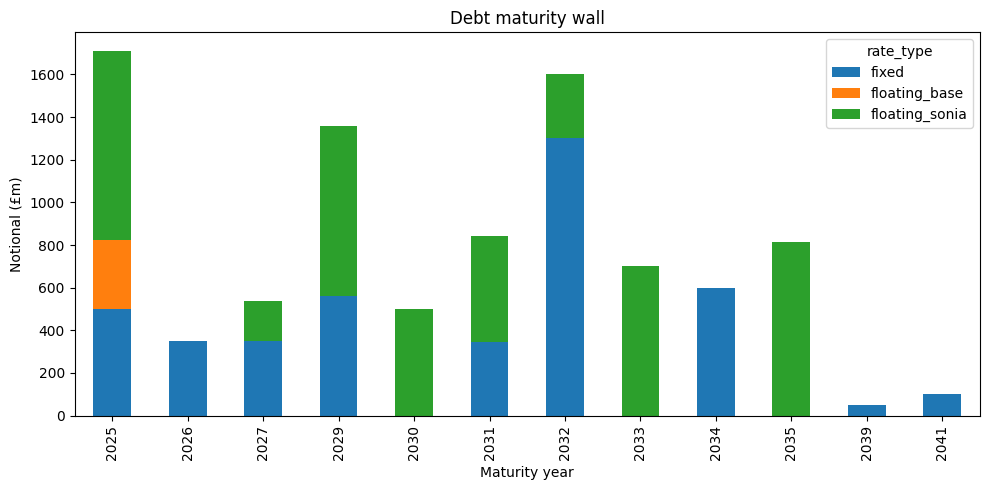

In [22]:
plot_maturity_wall(maturity_wall, output_path="outputs/maturity_wall.png")

In [23]:
years = np.arange(START_YEAR, START_YEAR + HORIZON_YEARS)

runoff_notional = []
for y in years:
    outstanding = debt.loc[debt["maturity_year"] >= y, "notional_gbp_m"].sum()
    runoff_notional.append(outstanding)

runoff_curve = pd.DataFrame({
    "year": years,
    "outstanding_gbp_m": runoff_notional
})

runoff_curve.head()

,year,outstanding_gbp_m
0,2025,9170
1,2026,7458
2,2027,7108
3,2028,6569
4,2029,6569


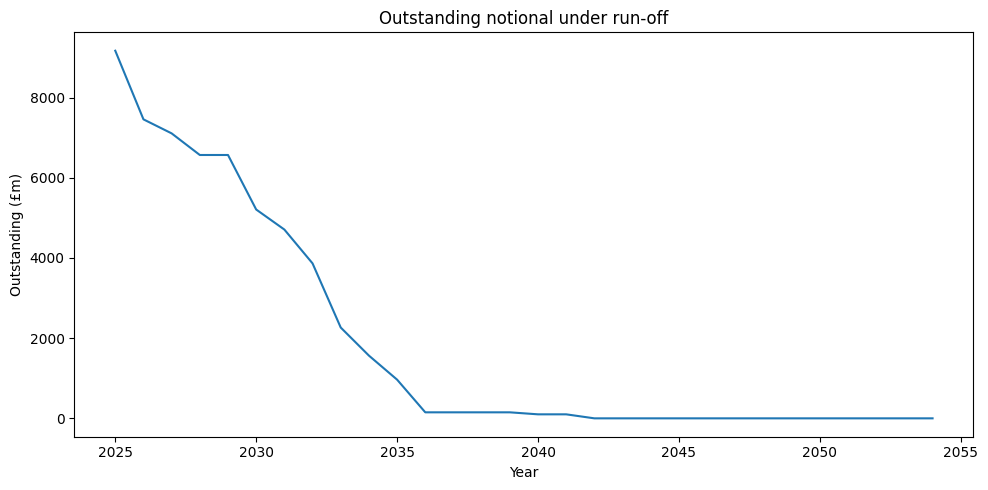

In [24]:
plot_runoff_outstanding(runoff_curve, output_path="outputs/runoff_outstanding.png")

In [25]:
scen = pd.read_csv(SCENARIO_PATH)
print(scen.head())
print(scen.columns.tolist())
print(scen.shape)

   scenario  year fiscal_year  sonia_rate  forward_rate  deviation  regime
0         0     0        FY26    0.040853      0.040853   0.000000  normal
1         0     1        FY27    0.000000      0.034313  -0.034313  crisis
2         0     2        FY28    0.019941      0.035024  -0.015083  normal
3         0     3        FY29    0.029093      0.037851  -0.008758  normal
4         0     4        FY30    0.034715      0.039965  -0.005250  normal
['scenario', 'year', 'fiscal_year', 'sonia_rate', 'forward_rate', 'deviation', 'regime']
(38000, 7)


In [26]:
rate_matrix = prepare_rate_matrix(
    scen_df=scen,
    scenario_col="scenario",
    year_col="year",
    rate_col="sonia_rate",
    horizon_years=HORIZON_YEARS
)

rate_matrix.head()

year,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
scenario,,,,,,,,,,,,,,,,,,,,,
0,0.040853,0.000000,0.019941,0.029093,0.034715,0.032598,0.031350,0.000000,0.004656,0.025410,...,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010
1,0.040853,0.037255,0.049277,0.054846,0.047426,0.055863,0.064062,0.023986,0.032941,0.044713,...,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555
2,0.040853,0.034987,0.038373,0.047471,0.043837,0.007504,0.050994,0.068577,0.076144,0.056751,...,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148
3,0.040853,0.033835,0.029307,0.034060,0.035046,0.037181,0.018378,0.012564,0.039419,0.043384,...,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003
4,0.040853,0.034960,0.035625,0.039207,0.043078,0.043494,0.048128,0.051474,0.071618,0.065942,...,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081


In [27]:
scen = pd.read_csv(SCENARIO_PATH)

print(scen.head())
print(scen.columns.tolist())
print(scen.shape)

# Optional QC
scen["reconstructed_rate"] = scen["forward_rate"] + scen["deviation"]
scen["check_diff"] = scen["sonia_rate"] - scen["reconstructed_rate"]
print("Max reconstruction error:", scen["check_diff"].abs().max())

# Core simulation input
rate_matrix = prepare_rate_matrix(
    scen_df=scen,
    scenario_col="scenario",
    year_col="year",
    rate_col="sonia_rate",
    horizon_years=HORIZON_YEARS
)

rate_matrix.head()

   scenario  year fiscal_year  sonia_rate  forward_rate  deviation  regime
0         0     0        FY26    0.040853      0.040853   0.000000  normal
1         0     1        FY27    0.000000      0.034313  -0.034313  crisis
2         0     2        FY28    0.019941      0.035024  -0.015083  normal
3         0     3        FY29    0.029093      0.037851  -0.008758  normal
4         0     4        FY30    0.034715      0.039965  -0.005250  normal
['scenario', 'year', 'fiscal_year', 'sonia_rate', 'forward_rate', 'deviation', 'regime']
(38000, 7)
Max reconstruction error: 1.3877787807814457e-17


year,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
scenario,,,,,,,,,,,,,,,,,,,,,
0,0.040853,0.000000,0.019941,0.029093,0.034715,0.032598,0.031350,0.000000,0.004656,0.025410,...,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010
1,0.040853,0.037255,0.049277,0.054846,0.047426,0.055863,0.064062,0.023986,0.032941,0.044713,...,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555
2,0.040853,0.034987,0.038373,0.047471,0.043837,0.007504,0.050994,0.068577,0.076144,0.056751,...,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148
3,0.040853,0.033835,0.029307,0.034060,0.035046,0.037181,0.018378,0.012564,0.039419,0.043384,...,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003
4,0.040853,0.034960,0.035625,0.039207,0.043078,0.043494,0.048128,0.051474,0.071618,0.065942,...,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081


In [28]:
runoff_interest, runoff_outstanding = simulate_runoff(
    debt_df=debt,
    rate_matrix=rate_matrix,
    start_year=START_YEAR,
    horizon_years=HORIZON_YEARS
)

refi_interest, refi_outstanding = simulate_full_refinancing(
    debt_df=debt,
    rate_matrix=rate_matrix,
    start_year=START_YEAR,
    horizon_years=HORIZON_YEARS,
    refi_term=20
)

In [29]:
runoff_stats = summarise_distribution(runoff_interest, years)
refi_stats = summarise_distribution(refi_interest, years)

runoff_cum = cumulative_summary(runoff_interest)
refi_cum = cumulative_summary(refi_interest)

runoff_stats.head(), refi_stats.head(), runoff_cum, refi_cum

(   year        mean          p5         p50         p95
 0  2025  444.425731  444.425731  444.425731  444.425731
 1  2026  337.369204  308.580003  334.636072  400.586045
 2  2027  323.113716  239.050388  320.382263  398.827665
 3  2028  311.468937  197.444663  309.001033  390.561578
 4  2029  320.482710  193.401828  319.291130  407.060619,
    year        mean          p5         p50         p95
 0  2025  444.425731  444.425731  444.425731  444.425731
 1  2026  407.309540  378.520339  404.576408  470.526381
 2  2027  405.011032  315.050613  402.264913  485.752504
 3  2028  412.673426  292.380959  410.256460  502.602421
 4  2029  421.687199  289.987853  420.288851  514.072262,
 {'mean': np.float64(2787.9180387),
  'p5': np.float64(2327.9479644999997),
  'p50': np.float64(2790.6433685),
  'p95': np.float64(3165.9580857500005)},
 {'mean': np.float64(12833.354159233499),
  'p5': np.float64(9084.39078025),
  'p50': np.float64(12933.108742),
  'p95': np.float64(16051.23326795)})

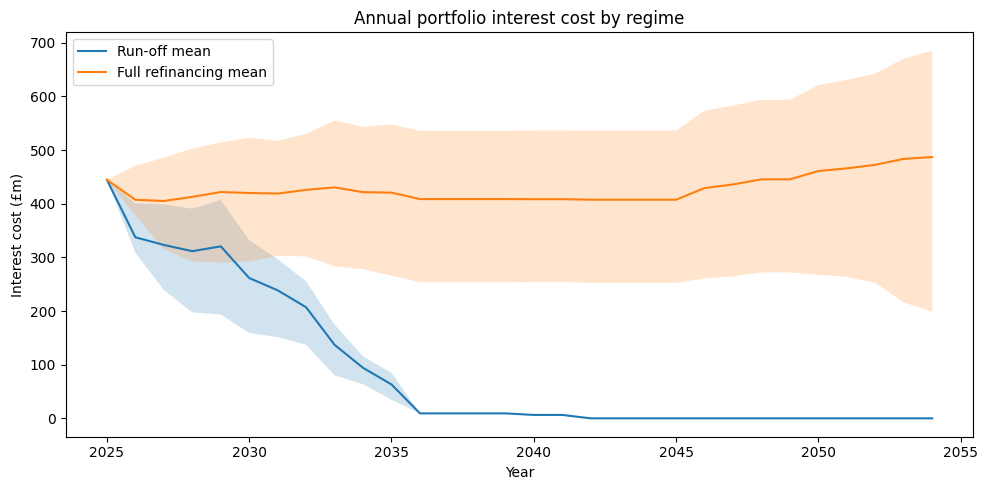

In [30]:
plot_interest_regimes(
    runoff_stats,
    refi_stats,
    output_path="outputs/interest_regimes.png"
)

In [31]:
high_risk_runoff = riskiest_years(runoff_stats, n=5)
high_risk_refi = riskiest_years(refi_stats, n=5)

print("Run-off")
display(high_risk_runoff)

print("Full refinancing")
display(high_risk_refi)

Run-off


,year,mean,p5,p50,p95,width_p95_p5
4,2029,320.482710,193.401828,319.291130,407.060619,213.658791
3,2028,311.468937,197.444663,309.001033,390.561578,193.116915
5,2030,261.450208,159.152831,260.926200,331.985104,172.832274
2,2027,323.113716,239.050388,320.382263,398.827665,159.777277
6,2031,238.599782,151.219574,239.428597,296.830990,145.611416


Full refinancing


,year,mean,p5,p50,p95,width_p95_p5
29,2054,486.889952,198.879168,499.096428,685.018178,486.139010
28,2053,483.448871,216.047394,495.540390,670.397300,454.349907
27,2052,472.378251,252.480252,482.600962,642.492138,390.011886
26,2051,465.813352,263.529407,475.357341,630.571722,367.042315
25,2050,460.848028,267.439975,470.119905,621.053256,353.613282


In [34]:
with pd.ExcelWriter("outputs/summary_tables.xlsx") as writer:
    debt.to_excel(writer, sheet_name="debt_stack", index=False)
    maturity_wall.to_excel(writer, sheet_name="maturity_wall")
    runoff_stats.to_excel(writer, sheet_name="runoff_interest", index=False)
    refi_stats.to_excel(writer, sheet_name="refi_interest", index=False)
    pd.DataFrame([runoff_cum]).to_excel(writer, sheet_name="runoff_cumulative", index=False)
    pd.DataFrame([refi_cum]).to_excel(writer, sheet_name="refi_cumulative", index=False)

print("Done")

Done


In [33]:
scenario_idx = 0

plt.figure(figsize=(10,5))
plt.plot(years, refi_interest[scenario_idx], marker="o")
plt.title("Regime B interest path for one scenario")
plt.xlabel("Year")
plt.ylabel("Annual interest cost (£m)")
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'plt' is not defined

In [35]:
display(summary)

display(runoff_stats.round(2))
display(refi_stats.round(2))

print("Run-off cumulative:")
print(runoff_cum)

print("Full refinancing cumulative:")
print(refi_cum)

display(high_risk_runoff.round(2))
display(high_risk_refi.round(2))

{'total_notional_gbp_m': np.int64(9170),
 'weighted_average_maturity_years': np.float64(5.720997777922085),
 'pct_fixed': 0.4528898582333697,
 'pct_floating_sonia': 0.5119956379498364,
 'pct_floating_base': 0.035114503816793895}

,year,mean,p5,p50,p95
0,2025,444.43,444.43,444.43,444.43
1,2026,337.37,308.58,334.64,400.59
2,2027,323.11,239.05,320.38,398.83
3,2028,311.47,197.44,309.00,390.56
4,2029,320.48,193.40,319.29,407.06
5,2030,261.45,159.15,260.93,331.99
6,2031,238.60,151.22,239.43,296.83
7,2032,206.97,137.10,208.76,255.14
8,2033,136.99,80.27,138.43,174.70
9,2034,94.12,63.43,94.98,115.40


,year,mean,p5,p50,p95
0,2025,444.43,444.43,444.43,444.43
1,2026,407.31,378.52,404.58,470.53
2,2027,405.01,315.05,402.26,485.75
3,2028,412.67,292.38,410.26,502.60
4,2029,421.69,289.99,420.29,514.07
5,2030,419.90,292.26,417.89,522.81
6,2031,418.83,302.65,419.04,517.11
7,2032,425.79,301.83,427.09,530.45
8,2033,430.33,283.17,432.58,555.06
9,2034,421.47,278.02,424.09,543.28


Run-off cumulative:
{'mean': np.float64(2787.9180387), 'p5': np.float64(2327.9479644999997), 'p50': np.float64(2790.6433685), 'p95': np.float64(3165.9580857500005)}
Full refinancing cumulative:
{'mean': np.float64(12833.354159233499), 'p5': np.float64(9084.39078025), 'p50': np.float64(12933.108742), 'p95': np.float64(16051.23326795)}


,year,mean,p5,p50,p95,width_p95_p5
4,2029,320.48,193.40,319.29,407.06,213.66
3,2028,311.47,197.44,309.00,390.56,193.12
5,2030,261.45,159.15,260.93,331.99,172.83
2,2027,323.11,239.05,320.38,398.83,159.78
6,2031,238.60,151.22,239.43,296.83,145.61


,year,mean,p5,p50,p95,width_p95_p5
29,2054,486.89,198.88,499.10,685.02,486.14
28,2053,483.45,216.05,495.54,670.40,454.35
27,2052,472.38,252.48,482.60,642.49,390.01
26,2051,465.81,263.53,475.36,630.57,367.04
25,2050,460.85,267.44,470.12,621.05,353.61


In [38]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_selected_scenario(scenario_idx=0):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Rate path
    axes[0].plot(years, 100 * rate_matrix.iloc[scenario_idx, :len(years)].values, marker="o")
    axes[0].set_title(f"Scenario {scenario_idx}: annual market refinancing rate")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Rate (%)")
    axes[0].grid(True, alpha=0.3)

    # Interest comparison
    axes[1].plot(years, runoff_interest[scenario_idx], label="Regime A: Run-off", marker="o")
    axes[1].plot(years, refi_interest[scenario_idx], label="Regime B: Full refinancing", marker="o")
    axes[1].set_title(f"Scenario {scenario_idx}: annual interest cost by regime")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Interest cost (£m)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

interact(
    plot_selected_scenario,
    scenario_idx=widgets.IntSlider(
        min=0,
        max=rate_matrix.shape[0] - 1,
        step=1,
        value=0,
        description="Scenario"
    )
);

interactive(children=(IntSlider(value=0, description='Scenario', max=1999), Output()), _dom_classes=('widget-i…

In [39]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_selected_scenario_regime(scenario_idx=0, regime="both"):
    plt.figure(figsize=(10, 5))

    if regime in ["runoff", "both"]:
        plt.plot(years, runoff_interest[scenario_idx], label="Regime A: Run-off", marker="o")

    if regime in ["refi", "both"]:
        plt.plot(years, refi_interest[scenario_idx], label="Regime B: Full refinancing", marker="o")

    plt.title(f"Scenario {scenario_idx}: annual interest cost")
    plt.xlabel("Year")
    plt.ylabel("Interest cost (£m)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    plot_selected_scenario_regime,
    scenario_idx=widgets.IntSlider(
        min=0,
        max=rate_matrix.shape[0] - 1,
        step=1,
        value=0,
        description="Scenario"
    ),
    regime=widgets.Dropdown(
        options=["both", "runoff", "refi"],
        value="both",
        description="Regime"
    )
);

interactive(children=(IntSlider(value=0, description='Scenario', max=1999), Dropdown(description='Regime', opt…

In [40]:
outputs/slide2_maturity_wall.png

NameError: name 'outputs' is not defined

In [41]:
outputs/slide3_runoff_interest.png

NameError: name 'outputs' is not defined

In [36]:
runoff_stats.to_csv("outputs/runoff_stats.csv", index=False)
refi_stats.to_csv("outputs/refi_stats.csv", index=False)
pd.DataFrame([runoff_cum]).to_csv("outputs/runoff_cumulative.csv", index=False)
pd.DataFrame([refi_cum]).to_csv("outputs/refi_cumulative.csv", index=False)

# Scottish Power Debt Interest Simulation

This notebook:
1. explains the debt stack clearly,
2. simulates annual interest under two refinancing regimes across 2,000 scenarios, and
3. outlines how the capability could become a user-facing treasury product.

## Assumptions

- Principal balances only are modelled; accrued interest balances are excluded.
- The zero-balance inflation-linked bond is excluded from the 2024 debt stack.
- The related-party SONIA + CAS + 0.78% borrowing due 20 Dec 2027 is split into:
  - £190m current tranche modelled as 2025 maturity
  - £190m non-current tranche modelled as 2027 maturity
- On-demand balances are bucketed into 2025 for annual maturity-wall purposes.
- Floating-rate debt is approximated as market rate plus contractual spread.
- Full refinancing assumes immediate issuance of a new 20-year fixed-rate bond at the scenario market rate in that year.
- The model uses annual time steps and annual interest approximations rather than exact coupon-date cashflows.

In [43]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.getcwd())

from src.debt_data import load_debt_table, debt_summary
from src.simulation import prepare_rate_matrix, simulate_runoff, simulate_full_refinancing
from src.metrics import summarise_distribution, cumulative_summary, riskiest_years

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

SCENARIO_PATH = "simulation_scenarios.csv"
START_YEAR = 2025
HORIZON_YEARS = 30

In [44]:
debt = load_debt_table()
scen = pd.read_csv(SCENARIO_PATH)

print("Debt rows:", debt.shape)
print("Scenario rows:", scen.shape)
print("Scenario columns:", scen.columns.tolist())

display(debt.head())
display(scen.head())

Debt rows: (23, 8)
Scenario rows: (38000, 7)
Scenario columns: ['scenario', 'year', 'fiscal_year', 'sonia_rate', 'forward_rate', 'deviation', 'regime']


,instrument,notional_gbp_m,rate_type,coupon_or_spread,maturity_date,rate_label,maturity_year,years_to_maturity
0,Related party loan OD 1,255,floating_base,0.01000,2025-06-30,Base + 1%,2025,0.495551
1,Related party loan OD 2,64,floating_base,0.03507,2025-06-30,Base + 3.507%,2025,0.495551
2,Related party loan OD 3,3,floating_base,0.01000,2025-06-30,Base + 1%,2025,0.495551
3,Related party loan,700,floating_sonia,0.00750,2025-01-31,SONIA + CAS + 0.75%,2025,0.084873
4,Related party loan,500,fixed,0.04106,2025-08-01,4.106%,2025,0.583162


,scenario,year,fiscal_year,sonia_rate,forward_rate,deviation,regime
0,0,0,FY26,0.040853,0.040853,0.000000,normal
1,0,1,FY27,0.000000,0.034313,-0.034313,crisis
2,0,2,FY28,0.019941,0.035024,-0.015083,normal
3,0,3,FY29,0.029093,0.037851,-0.008758,normal
4,0,4,FY30,0.034715,0.039965,-0.005250,normal


In [45]:
# Clean presentation bucket for slide charts
debt["rate_group"] = np.where(debt["rate_type"] == "fixed", "fixed", "floating")

# Core debt summary
summary_dict = debt_summary(debt)

total_notional = debt["notional_gbp_m"].sum()
wam = np.average(debt["years_to_maturity"], weights=debt["notional_gbp_m"])

rate_mix_group = (
    debt.groupby("rate_group")["notional_gbp_m"].sum() / total_notional
).sort_values(ascending=False)

maturity_by_year = debt.groupby("maturity_year")["notional_gbp_m"].sum().sort_index()
pct_maturing_by_2035 = maturity_by_year.loc[maturity_by_year.index <= 2035].sum() / total_notional
top_maturity_years = maturity_by_year.sort_values(ascending=False).head(5)

debt_summary_pack = {
    "total_notional_gbp_m": total_notional,
    "wam_years": wam,
    "rate_mix_group": (100 * rate_mix_group).round(1).to_dict(),
    "pct_maturing_by_2035": round(100 * pct_maturing_by_2035, 1),
    "top_maturity_years_gbp_m": top_maturity_years.to_dict(),
}

debt_summary_pack

{'total_notional_gbp_m': np.int64(9170),
 'wam_years': np.float64(5.720997777922085),
 'rate_mix_group': {'floating': 54.7, 'fixed': 45.3},
 'pct_maturing_by_2035': np.float64(98.4),
 'top_maturity_years_gbp_m': {2025: 1712,
  2032: 1600,
  2029: 1360,
  2031: 844,
  2035: 815}}

In [46]:
maturity_wall = (
    debt.groupby(["maturity_year", "rate_group"])["notional_gbp_m"]
    .sum()
    .unstack(fill_value=0)
    .reindex(range(START_YEAR, START_YEAR + HORIZON_YEARS), fill_value=0)
)

maturity_wall.head(15)

rate_group,fixed,floating
maturity_year,,
2025,500,1212
2026,350,0
2027,349,190
2028,0,0
2029,560,800
2030,0,500
2031,344,500
2032,1300,300
2033,0,700


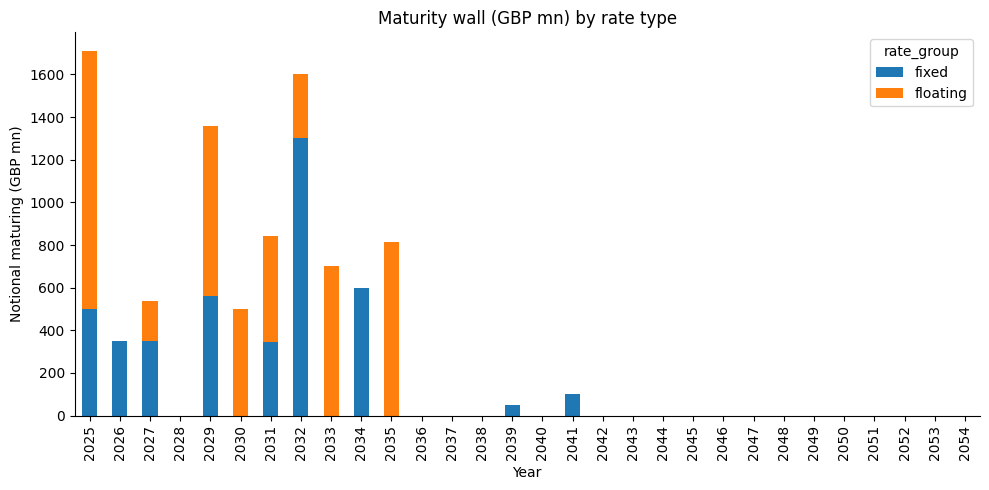

In [47]:
ax = maturity_wall.plot(kind="bar", stacked=True)
ax.set_title("Maturity wall (GBP mn) by rate type")
ax.set_xlabel("Year")
ax.set_ylabel("Notional maturing (GBP mn)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "slide2_maturity_wall.png", dpi=200)
plt.show()

In [48]:
# Optional QC: check scenario construction
scen["reconstructed_rate"] = scen["forward_rate"] + scen["deviation"]
scen["check_diff"] = scen["sonia_rate"] - scen["reconstructed_rate"]

print("Max scenario reconstruction error:", scen["check_diff"].abs().max())

Max scenario reconstruction error: 1.3877787807814457e-17


In [50]:
rate_matrix = prepare_rate_matrix(
    scen_df=scen,
    scenario_col="scenario",
    year_col="year",
    rate_col="sonia_rate",
    horizon_years=HORIZON_YEARS
)

years = np.arange(START_YEAR, START_YEAR + HORIZON_YEARS)

print(rate_matrix.shape)
display(rate_matrix.head())

(2000, 30)


year,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
scenario,,,,,,,,,,,,,,,,,,,,,
0,0.040853,0.000000,0.019941,0.029093,0.034715,0.032598,0.031350,0.000000,0.004656,0.025410,...,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010
1,0.040853,0.037255,0.049277,0.054846,0.047426,0.055863,0.064062,0.023986,0.032941,0.044713,...,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555
2,0.040853,0.034987,0.038373,0.047471,0.043837,0.007504,0.050994,0.068577,0.076144,0.056751,...,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148
3,0.040853,0.033835,0.029307,0.034060,0.035046,0.037181,0.018378,0.012564,0.039419,0.043384,...,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003
4,0.040853,0.034960,0.035625,0.039207,0.043078,0.043494,0.048128,0.051474,0.071618,0.065942,...,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081


In [51]:
runoff_interest, runoff_outstanding = simulate_runoff(
    debt_df=debt,
    rate_matrix=rate_matrix,
    start_year=START_YEAR,
    horizon_years=HORIZON_YEARS
)

refi_interest, refi_outstanding = simulate_full_refinancing(
    debt_df=debt,
    rate_matrix=rate_matrix,
    start_year=START_YEAR,
    horizon_years=HORIZON_YEARS,
    refi_term=20
)

In [52]:
runoff_stats = summarise_distribution(runoff_interest, years)
refi_stats = summarise_distribution(refi_interest, years)

runoff_cum = cumulative_summary(runoff_interest)
refi_cum = cumulative_summary(refi_interest)

runoff_stats["width_p95_p5"] = runoff_stats["p95"] - runoff_stats["p5"]
refi_stats["width_p95_p5"] = refi_stats["p95"] - refi_stats["p5"]

high_risk_runoff = runoff_stats.nlargest(5, "width_p95_p5")[["year", "mean", "p5", "p95", "width_p95_p5"]]
high_risk_refi = refi_stats.nlargest(5, "width_p95_p5")[["year", "mean", "p5", "p95", "width_p95_p5"]]

display(runoff_stats.head())
display(refi_stats.head())

print("Run-off cumulative:", runoff_cum)
print("Full refi cumulative:", refi_cum)

,year,mean,p5,p50,p95,width_p95_p5
0,2025,444.425731,444.425731,444.425731,444.425731,0.000000
1,2026,337.369204,308.580003,334.636072,400.586045,92.006041
2,2027,323.113716,239.050388,320.382263,398.827665,159.777277
3,2028,311.468937,197.444663,309.001033,390.561578,193.116915
4,2029,320.482710,193.401828,319.291130,407.060619,213.658791


,year,mean,p5,p50,p95,width_p95_p5
0,2025,444.425731,444.425731,444.425731,444.425731,0.000000
1,2026,407.309540,378.520339,404.576408,470.526381,92.006041
2,2027,405.011032,315.050613,402.264913,485.752504,170.701891
3,2028,412.673426,292.380959,410.256460,502.602421,210.221462
4,2029,421.687199,289.987853,420.288851,514.072262,224.084410


Run-off cumulative: {'mean': np.float64(2787.9180387), 'p5': np.float64(2327.9479644999997), 'p50': np.float64(2790.6433685), 'p95': np.float64(3165.9580857500005)}
Full refi cumulative: {'mean': np.float64(12833.354159233499), 'p5': np.float64(9084.39078025), 'p50': np.float64(12933.108742), 'p95': np.float64(16051.23326795)}


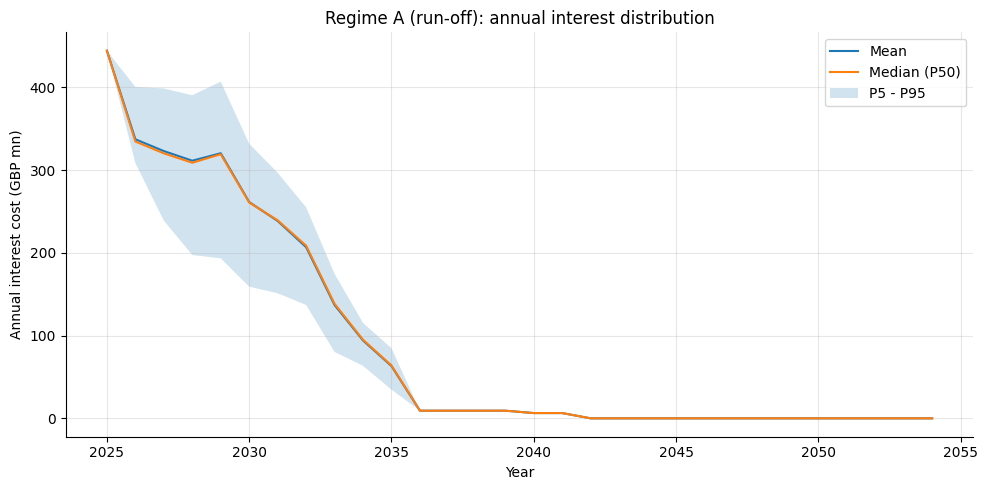

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(runoff_stats["year"], runoff_stats["mean"], label="Mean")
plt.plot(runoff_stats["year"], runoff_stats["p50"], label="Median (P50)")
plt.fill_between(runoff_stats["year"], runoff_stats["p5"], runoff_stats["p95"], alpha=0.2, label="P5 - P95")
plt.title("Regime A (run-off): annual interest distribution")
plt.xlabel("Year")
plt.ylabel("Annual interest cost (GBP mn)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "slide3_runoff_interest.png", dpi=200)
plt.show()

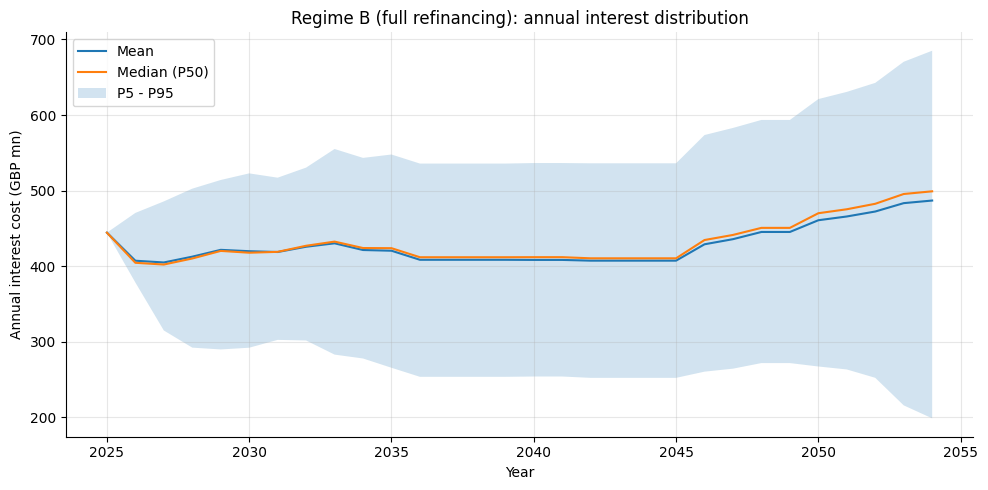

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(refi_stats["year"], refi_stats["mean"], label="Mean")
plt.plot(refi_stats["year"], refi_stats["p50"], label="Median (P50)")
plt.fill_between(refi_stats["year"], refi_stats["p5"], refi_stats["p95"], alpha=0.2, label="P5 - P95")
plt.title("Regime B (full refinancing): annual interest distribution")
plt.xlabel("Year")
plt.ylabel("Annual interest cost (GBP mn)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "slide4_refi_interest.png", dpi=200)
plt.show()

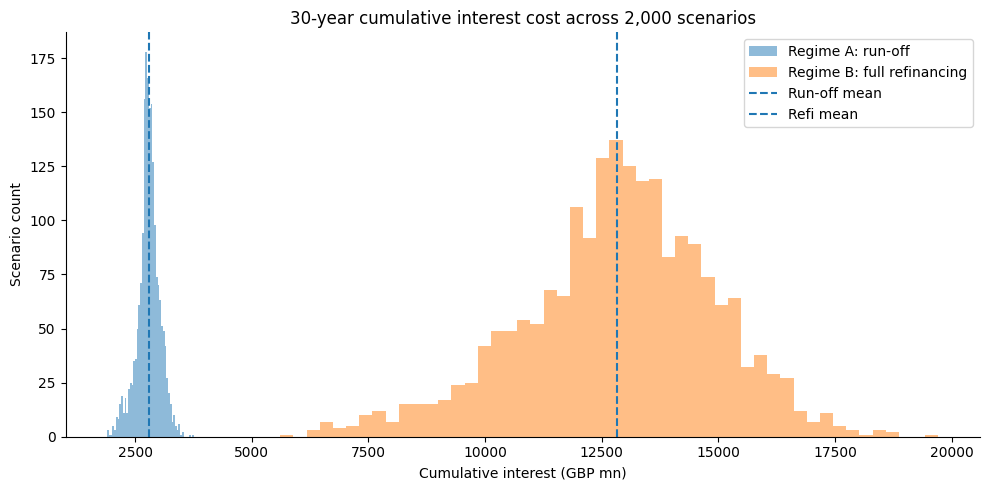

In [55]:
cum_run = runoff_interest.sum(axis=1)
cum_ref = refi_interest.sum(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(cum_run, bins=50, alpha=0.5, label="Regime A: run-off")
plt.hist(cum_ref, bins=50, alpha=0.5, label="Regime B: full refinancing")

plt.axvline(np.mean(cum_run), linestyle="--", label="Run-off mean")
plt.axvline(np.mean(cum_ref), linestyle="--", label="Refi mean")

plt.title("30-year cumulative interest cost across 2,000 scenarios")
plt.xlabel("Cumulative interest (GBP mn)")
plt.ylabel("Scenario count")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "slide5_cumulative_hist.png", dpi=200)
plt.show()

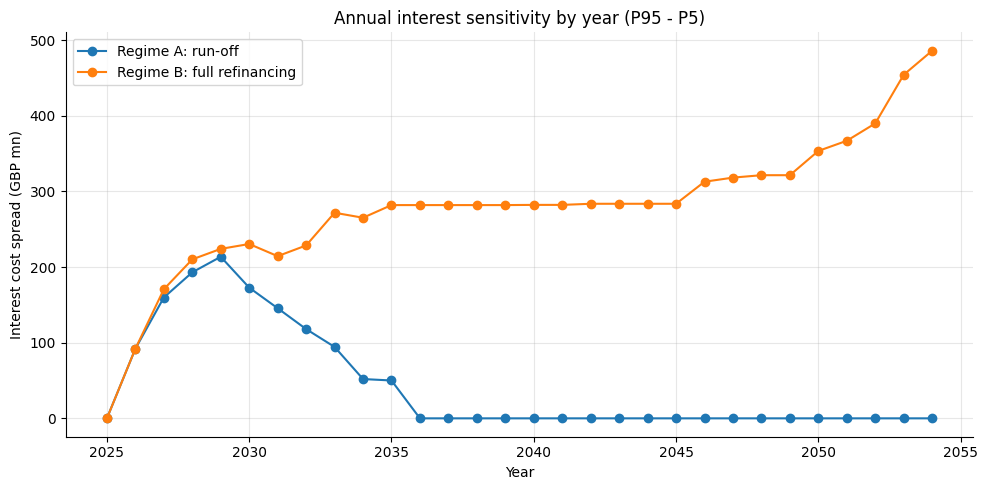

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(runoff_stats["year"], runoff_stats["width_p95_p5"], marker="o", label="Regime A: run-off")
plt.plot(refi_stats["year"], refi_stats["width_p95_p5"], marker="o", label="Regime B: full refinancing")
plt.title("Annual interest sensitivity by year (P95 - P5)")
plt.xlabel("Year")
plt.ylabel("Interest cost spread (GBP mn)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "slide6_risk_widths.png", dpi=200)
plt.show()

In [57]:
print("Top risk years — Run-off")
display(high_risk_runoff)

print("Top risk years — Full refinancing")
display(high_risk_refi)

Top risk years — Run-off


,year,mean,p5,p95,width_p95_p5
4,2029,320.482710,193.401828,407.060619,213.658791
3,2028,311.468937,197.444663,390.561578,193.116915
5,2030,261.450208,159.152831,331.985104,172.832274
2,2027,323.113716,239.050388,398.827665,159.777277
6,2031,238.599782,151.219574,296.830990,145.611416


Top risk years — Full refinancing


,year,mean,p5,p95,width_p95_p5
29,2054,486.889952,198.879168,685.018178,486.139010
28,2053,483.448871,216.047394,670.397300,454.349907
27,2052,472.378251,252.480252,642.492138,390.011886
26,2051,465.813352,263.529407,630.571722,367.042315
25,2050,460.848028,267.439975,621.053256,353.613282


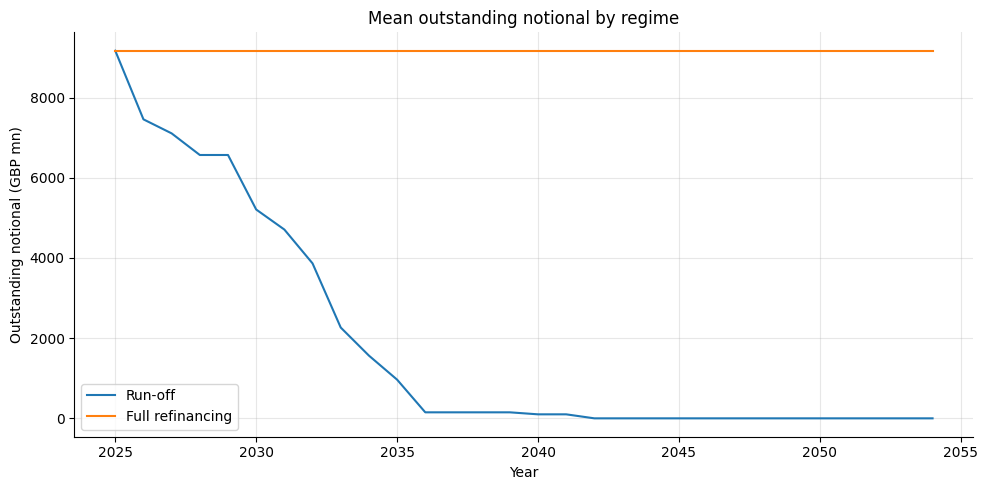

In [58]:
# Sanity checks

outstanding_runoff_mean = runoff_outstanding.mean(axis=0)
outstanding_refi_mean = refi_outstanding.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(years, outstanding_runoff_mean, label="Run-off")
plt.plot(years, outstanding_refi_mean, label="Full refinancing")
plt.title("Mean outstanding notional by regime")
plt.xlabel("Year")
plt.ylabel("Outstanding notional (GBP mn)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "appendix_outstanding_check.png", dpi=200)
plt.show()

In [59]:
# Slide-ready numbers

fixed_pct = debt_summary_pack["rate_mix_group"].get("fixed", 0.0)
floating_pct = debt_summary_pack["rate_mix_group"].get("floating", 0.0)

runoff_top_years_str = ", ".join(str(int(y)) for y in high_risk_runoff["year"].head(3).tolist())
refi_top_years_str = ", ".join(str(int(y)) for y in high_risk_refi["year"].head(3).tolist())

print("SLIDE 2")
print(f"Total notional: £{total_notional/1000:.2f}bn")
print(f"Weighted-average maturity: {wam:.1f} years")
print(f"Rate mix: fixed {fixed_pct:.1f}%, floating {floating_pct:.1f}%")
print(f"Share maturing by 2035: {debt_summary_pack['pct_maturing_by_2035']:.1f}%")
print(f"Top maturity years (£m): {debt_summary_pack['top_maturity_years_gbp_m']}")

print("\nSLIDE 3")
print(f"Run-off cumulative cost (mean / P50 / P95): "
      f"{runoff_cum['mean']:.0f} / {runoff_cum['p50']:.0f} / {runoff_cum['p95']:.0f} GBP mn")
print(f"Most sensitive run-off years: {runoff_top_years_str}")

print("\nSLIDE 4")
print(f"Full refinancing cumulative cost (mean / P50 / P95): "
      f"{refi_cum['mean']:.0f} / {refi_cum['p50']:.0f} / {refi_cum['p95']:.0f} GBP mn")
print(f"Most sensitive full refinancing years: {refi_top_years_str}")

print("\nSLIDE 5")
print(f"Difference in mean cumulative cost (Refi - Run-off): "
      f"{(refi_cum['mean'] - runoff_cum['mean']):.0f} GBP mn")

SLIDE 2
Total notional: £9.17bn
Weighted-average maturity: 5.7 years
Rate mix: fixed 45.3%, floating 54.7%
Share maturing by 2035: 98.4%
Top maturity years (£m): {2025: 1712, 2032: 1600, 2029: 1360, 2031: 844, 2035: 815}

SLIDE 3
Run-off cumulative cost (mean / P50 / P95): 2788 / 2791 / 3166 GBP mn
Most sensitive run-off years: 2029, 2028, 2030

SLIDE 4
Full refinancing cumulative cost (mean / P50 / P95): 12833 / 12933 / 16051 GBP mn
Most sensitive full refinancing years: 2054, 2053, 2052

SLIDE 5
Difference in mean cumulative cost (Refi - Run-off): 10045 GBP mn


## How SONIA-linked refinancing would differ

In the current full-refinancing regime, maturing debt is refinanced into a new 20-year fixed-rate bond, so uncertainty is converted into refinancing-timing risk at issuance.

If refinancing were SONIA-linked instead:
- coupons would continue to reset after issuance,
- the portfolio would retain ongoing floating-rate exposure,
- the annual interest distribution would likely remain wider for longer,
- modelling would require additional data such as reset frequency, compounding convention, spread, day count, lookback/lockout rules, and payment dates.

## Product feature and TMS integration

### Strategy UI
A treasury user should be able to:
- load the debt stack and choose a scenario set,
- define refinancing rules,
- run the simulation,
- compare expected cost and tail risk across strategies.

### Example user stories
- Compare strategies under alternative rate environments before issuance decisions.
- Identify the maturity years creating the greatest refinancing risk.
- Reproduce any run with a full assumptions and audit trail.

### Minimum extra data needed
For SONIA-linked debt:
- reset frequency,
- spread / margin,
- day count,
- compounding method,
- payment dates,
- lookback / lockout convention.

For index-linked debt:
- index reference,
- lag convention,
- uplift formula,
- base index level,
- real vs nominal coupon structure,
- redemption / principal accretion rules.

### TMS integration
- ingest positions, trades, identifiers, and cashflow schedules from the TMS,
- source market curves and scenario sets,
- export projected interest cashflows and risk reports,
- maintain versioning, approvals, and audit trail controls.

In [61]:
# Export tables used in the deck / appendix

with pd.ExcelWriter(OUTPUT_DIR / "results_pack.xlsx") as writer:
    debt.to_excel(writer, sheet_name="debt_stack", index=False)
    maturity_wall.to_excel(writer, sheet_name="maturity_wall")
    runoff_stats.to_excel(writer, sheet_name="runoff_interest", index=False)
    refi_stats.to_excel(writer, sheet_name="refi_interest", index=False)
    pd.DataFrame([runoff_cum]).to_excel(writer, sheet_name="runoff_cumulative", index=False)
    pd.DataFrame([refi_cum]).to_excel(writer, sheet_name="refi_cumulative", index=False)
    high_risk_runoff.to_excel(writer, sheet_name="high_risk_runoff", index=False)
    high_risk_refi.to_excel(writer, sheet_name="high_risk_refi", index=False)

print("Saved:")
for f in sorted(os.listdir("outputs")):
    print("-", f)

Saved:
- appendix_outstanding_check.png
- interest_regimes.png
- maturity_wall.png
- refi_cumulative.csv
- refi_stats.csv
- results_pack.xlsx
- runoff_cumulative.csv
- runoff_outstanding.png
- runoff_stats.csv
- slide2_maturity_wall.png
- slide3_runoff_interest.png
- slide4_refi_interest.png
- slide5_cumulative_hist.png
- slide6_risk_widths.png
- summary_tables.xlsx


In [62]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_selected_scenario(scenario_idx=0, regime="both"):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Top chart: rate path for selected scenario
    axes[0].plot(
        years,
        100 * rate_matrix.iloc[scenario_idx, :len(years)].values,
        marker="o"
    )
    axes[0].set_title(f"Scenario {scenario_idx}: annual market refinancing rate")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Rate (%)")
    axes[0].grid(True, alpha=0.3)

    # Bottom chart: interest by regime
    if regime in ["runoff", "both"]:
        axes[1].plot(
            years,
            runoff_interest[scenario_idx],
            label="Regime A: Run-off",
            marker="o"
        )

    if regime in ["refi", "both"]:
        axes[1].plot(
            years,
            refi_interest[scenario_idx],
            label="Regime B: Full refinancing",
            marker="o"
        )

    axes[1].set_title(f"Scenario {scenario_idx}: annual interest cost")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Interest cost (GBP mn)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

interact(
    plot_selected_scenario,
    scenario_idx=widgets.IntSlider(
        min=0,
        max=rate_matrix.shape[0] - 1,
        step=1,
        value=0,
        description="Scenario"
    ),
    regime=widgets.Dropdown(
        options=["both", "runoff", "refi"],
        value="both",
        description="Regime"
    )
);

interactive(children=(IntSlider(value=0, description='Scenario', max=1999), Dropdown(description='Regime', opt…